In [2]:
# ============================================
# IMPORTS & DATA LOADING
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv
import os
from sqlalchemy import create_engine, text

# Load environment variables
load_dotenv()

# Database connection
connection_string = (
    f"postgresql+psycopg2://"
    f"{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}"
    f"/{os.getenv('DB_NAME')}"
)
engine = create_engine(connection_string)

# Load datasets from PostgreSQL
providers = pd.read_sql("SELECT * FROM providers", engine)
receivers = pd.read_sql("SELECT * FROM receivers", engine)
food_listings = pd.read_sql("SELECT * FROM food_listings", engine)
claims = pd.read_sql("SELECT * FROM claims", engine)

print("Datasets loaded from PostgreSQL:")
print(f"  Providers:     {providers.shape}")
print(f"  Receivers:     {receivers.shape}")
print(f"  Food Listings: {food_listings.shape}")
print(f"  Claims:        {claims.shape}")

Datasets loaded from PostgreSQL:
  Providers:     (1000, 6)
  Receivers:     (1000, 5)
  Food Listings: (1000, 9)
  Claims:        (1000, 5)


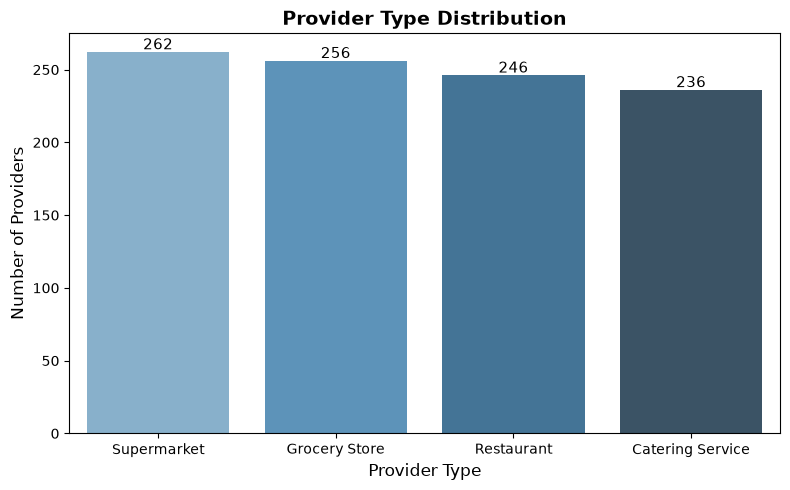

In [5]:
# ============================================
# PROVIDER TYPE DISTRIBUTION
# ============================================
import matplotlib.pyplot as plt
import seaborn as sns

provider_type_counts = providers["Type"].value_counts().reset_index()
provider_type_counts.columns = ["Provider_Type", "Count"]

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=provider_type_counts,
    x="Provider_Type",
    y="Count",
    hue="Provider_Type",
    palette="Blues_d",
    legend=False
)

plt.title("Provider Type Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Provider Type", fontsize=12)
plt.ylabel("Number of Providers", fontsize=12)

# Value labels on bars
for i, row in provider_type_counts.iterrows():
    ax.text(
        i,
        row["Count"] + 2,
        str(row["Count"]),
        ha="center",
        fontsize=11
    )

plt.tight_layout()
plt.savefig("Image/provider_type_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### Insight
Provider participation is relatively balanced across all four provider categories.
Supermarkets contribute the largest share of providers (262), followed closely by Grocery Stores (256), Restaurants (246), and Catering Services (236).
The small differences between categories suggest the platform is not heavily dependent on a single provider type, indicating a diversified food donation network.

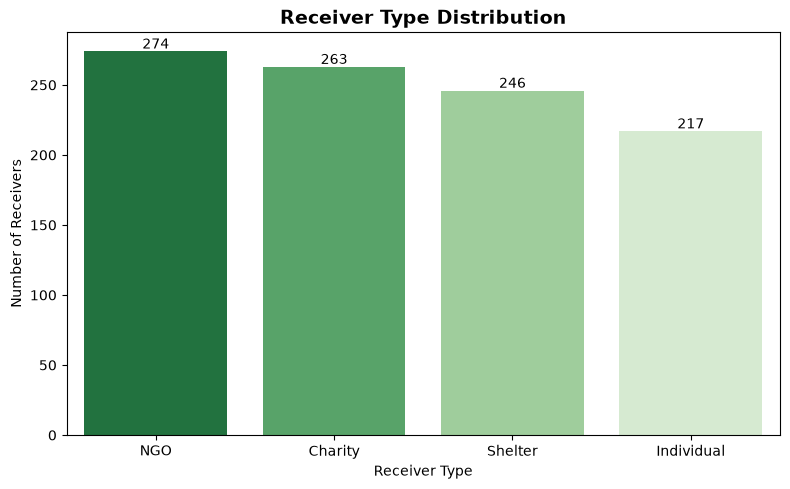

In [7]:
# ============================================
# RECEIVER TYPE DISTRIBUTION
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

receiver_type_counts = (
    receivers["Type"]
    .value_counts()
    .reset_index()
)

receiver_type_counts.columns = [
    "Receiver_Type",
    "Count"
]

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=receiver_type_counts,
    x="Receiver_Type",
    y="Count",
    hue="Receiver_Type",
    palette="Greens_r",
    legend=False
)

plt.title(
    "Receiver Type Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Receiver Type")
plt.ylabel("Number of Receivers")

# Value labels on bars
for i, row in receiver_type_counts.iterrows():
    ax.text(
        i,
        row["Count"] + 2,
        str(row["Count"]),
        ha="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "Image/receiver_type_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Insight

NGOs represent the largest beneficiary group on the platform with 274 receivers, followed by Charities (263) and Shelters (246), while Individuals account for 217 receivers. The relatively balanced distribution suggests that food redistribution efforts are reaching a diverse mix of recipients rather than being concentrated in a single group. From a stakeholder perspective, the strong participation of NGOs, Charities, and Shelters indicates that the platform is successfully engaging organizations that support vulnerable populations and community welfare.

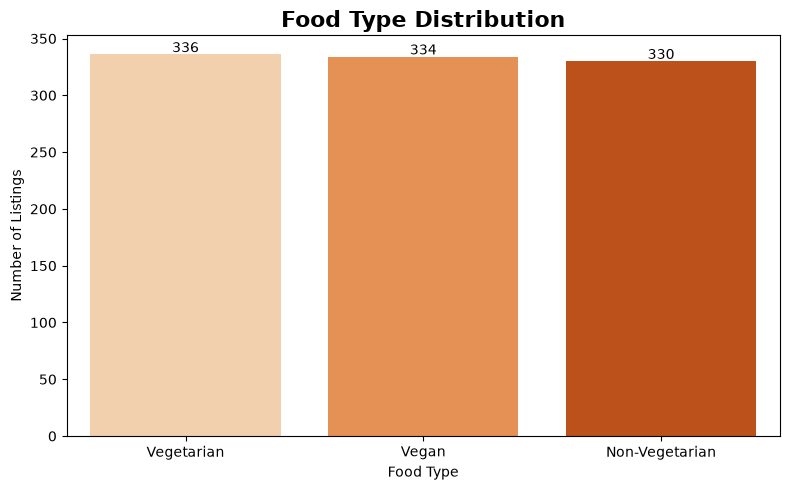

In [8]:
# ============================================
# FOOD TYPE DISTRIBUTION
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

food_type_counts = (
    food_listings["Food_Type"]
    .value_counts()
    .reset_index()
)

food_type_counts.columns = ["Food_Type", "Count"]

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=food_type_counts,
    x="Food_Type",
    y="Count",
    hue="Food_Type",
    palette="Oranges",
    legend=False
)

plt.title("Food Type Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Food Type")
plt.ylabel("Number of Listings")

# Value annotations
for i, row in food_type_counts.iterrows():
    ax.text(
        i,
        row["Count"] + 2,
        str(row["Count"]),
        ha="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "Image/food_type_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Insight

The platform maintains a highly balanced distribution of food types, with Vegetarian (336), Vegan (334), and Non-Vegetarian (330) listings appearing in nearly equal proportions. This suggests that food availability is not concentrated in a single dietary category, allowing the platform to support a broad range of recipient dietary preferences and requirements. For stakeholders, the balanced inventory indicates an inclusive food supply that can serve diverse beneficiary groups without significant dietary bias.

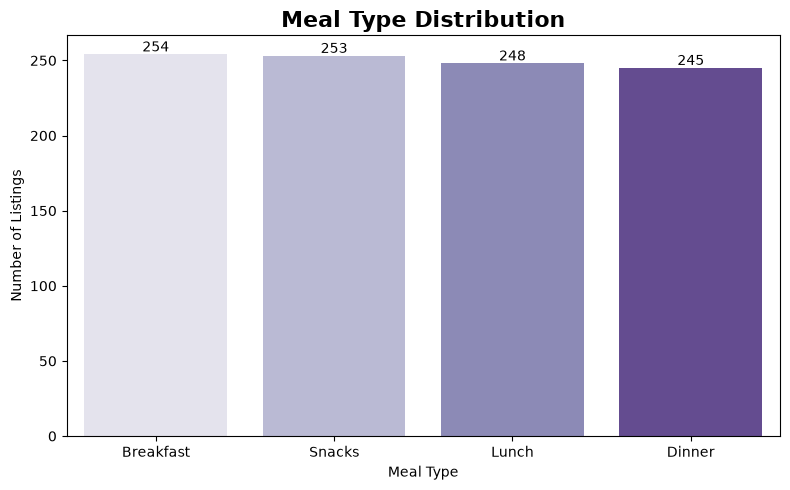

In [9]:
# ============================================
# MEAL TYPE DISTRIBUTION
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

meal_type_counts = (
    food_listings["Meal_Type"]
    .value_counts()
    .reset_index()
)

meal_type_counts.columns = ["Meal_Type", "Count"]

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=meal_type_counts,
    x="Meal_Type",
    y="Count",
    hue="Meal_Type",
    palette="Purples",
    legend=False
)

plt.title(
    "Meal Type Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Meal Type")
plt.ylabel("Number of Listings")

# Value labels
for i, row in meal_type_counts.iterrows():
    ax.text(
        i,
        row["Count"] + 2,
        str(row["Count"]),
        ha="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "Image/meal_type_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Insight

The platform maintains a balanced distribution of meal offerings, with Breakfast (254) and Snacks (253) appearing slightly more frequently than Lunch (248) and Dinner (245). The small differences across categories suggest that food availability is spread consistently throughout the day rather than being concentrated around a specific meal period. For stakeholders, this indicates that recipients have access to a diverse mix of meal options, supporting food redistribution needs across multiple consumption occasions.

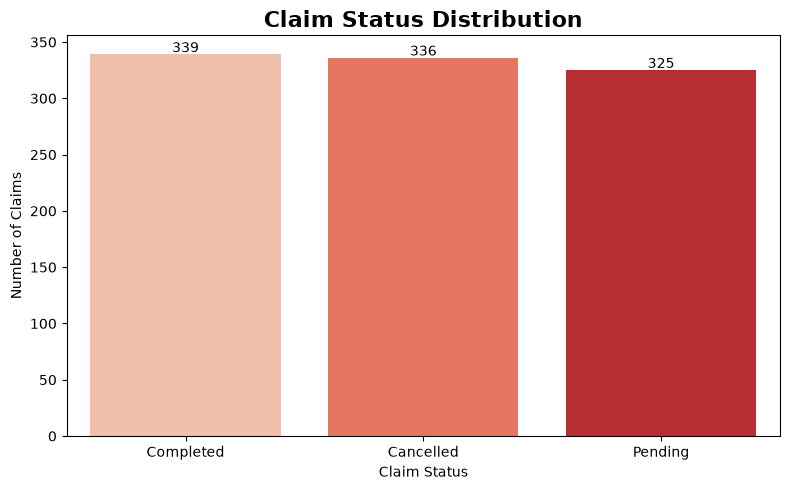

In [10]:
# ============================================
# CLAIM STATUS DISTRIBUTION
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

claim_status_counts = (
    claims["Status"]
    .value_counts()
    .reset_index()
)

claim_status_counts.columns = ["Status", "Count"]

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=claim_status_counts,
    x="Status",
    y="Count",
    hue="Status",
    palette="Reds",
    legend=False
)

plt.title(
    "Claim Status Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Claim Status")
plt.ylabel("Number of Claims")

# Value labels
for i, row in claim_status_counts.iterrows():
    ax.text(
        i,
        row["Count"] + 2,
        str(row["Count"]),
        ha="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "Image/claim_status_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Insight

Completed claims account for 339 records (33.9%), slightly exceeding Cancelled (336) and Pending (325) claims. While completed claims represent the largest category, the near-equal distribution across all three statuses suggests that a substantial portion of food requests are either not finalized or remain unresolved. With a claim completion rate of only 33.9%, the platform has significant room to improve food redistribution efficiency by reducing cancellations and accelerating claim fulfillment. From a stakeholder perspective, this chart highlights operational effectiveness rather than platform participation, making it one of the most important indicators of overall platform performance.

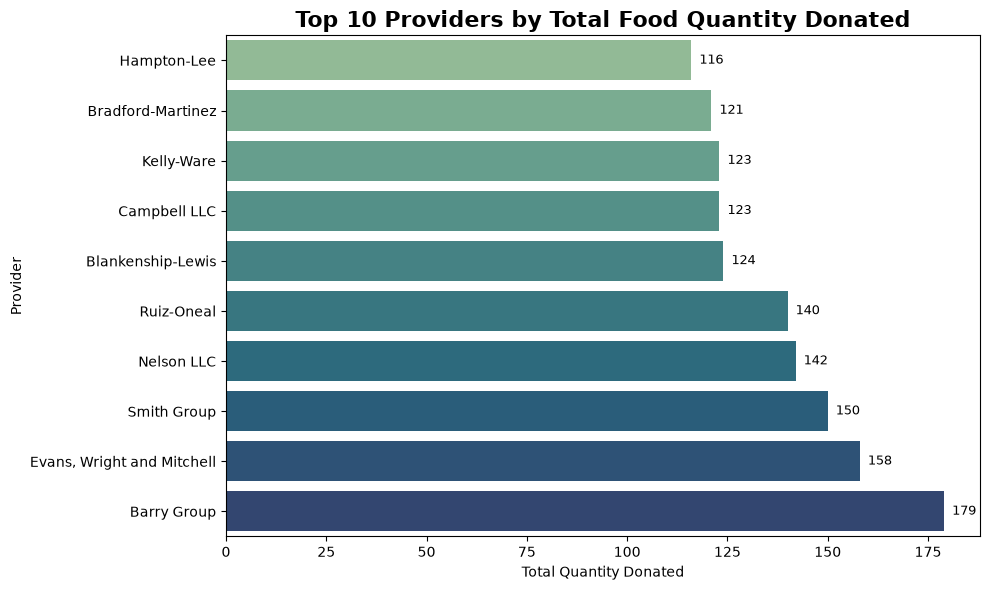

In [13]:
# ============================================
# TOP 10 PROVIDERS BY FOOD QUANTITY
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

provider_quantity = (
    food_listings
    .groupby("Provider_ID")["Quantity"]
    .sum()
    .reset_index()
    .rename(columns={"Quantity": "Total_Quantity"})
)

provider_quantity = provider_quantity.merge(
    providers[["Provider_ID", "Name"]],
    on="Provider_ID",
    how="left"
)

top_10_providers = (
    provider_quantity
 .nlargest(10, "Total_Quantity")
.sort_values("Total_Quantity")
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=top_10_providers,
    x="Total_Quantity",
    y="Name",
    hue="Name",
    palette="crest",
    legend=False
)

plt.title(
    "Top 10 Providers by Total Food Quantity Donated",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Total Quantity Donated")
plt.ylabel("Provider")

# Value annotations
for i, value in enumerate(top_10_providers["Total_Quantity"]):
    ax.text(
        value + 2,
        i,
        str(value),
        va="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "Image/top_10_providers_quantity.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Insight

The top 10 providers contribute substantially larger food quantities than the average provider, highlighting a small group of high-impact donors within the platform. Barry Group leads all providers with 179 units donated, approximately 54% more than Hampton-Lee, which contributes 116 units at the lower end of the top 10. Unlike listing counts, which measure activity, total quantity donated reflects the actual volume of food made available for redistribution and therefore provides a stronger indicator of provider impact. For stakeholders, these top contributors represent valuable partners whose continued participation can significantly influence the platform's ability to reduce food waste and support recipient organizations.

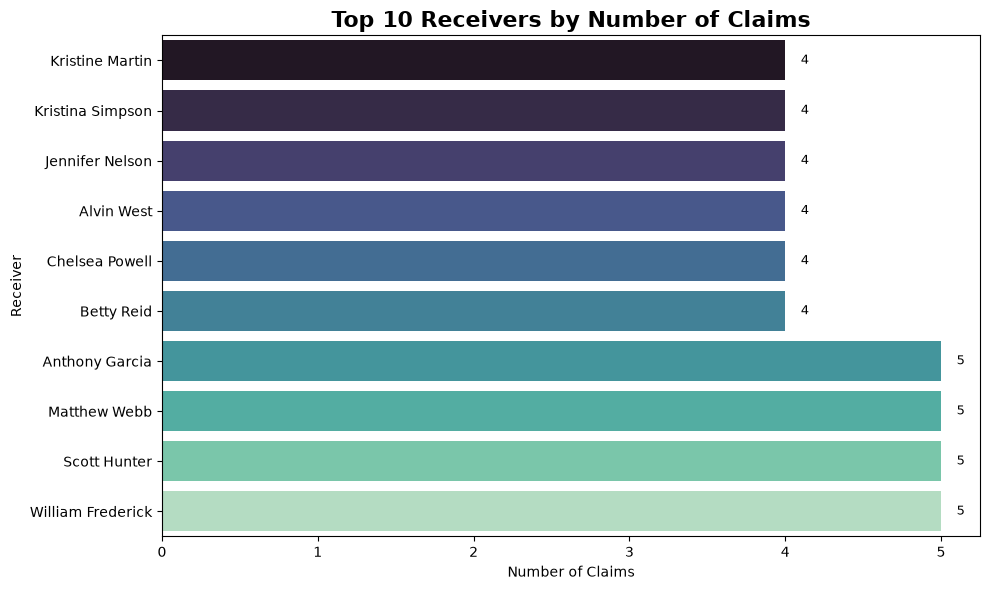

In [14]:
# ============================================
# TOP 10 RECEIVERS BY NUMBER OF CLAIMS
# ============================================

receiver_claims = (
    claims
    .groupby("Receiver_ID")["Claim_ID"]
    .count()
    .reset_index()
    .rename(columns={"Claim_ID": "Total_Claims"})
)

receiver_claims = receiver_claims.merge(
    receivers[["Receiver_ID", "Name"]],
    on="Receiver_ID",
    how="left"
)

top_10_receivers = (
    receiver_claims
    .nlargest(10, "Total_Claims")
    .sort_values("Total_Claims")
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=top_10_receivers,
    x="Total_Claims",
    y="Name",
    hue="Name",
    palette="mako",
    legend=False
)

plt.title(
    "Top 10 Receivers by Number of Claims",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Claims")
plt.ylabel("Receiver")

# Value labels
for i, value in enumerate(top_10_receivers["Total_Claims"]):
    ax.text(
        value + 0.1,
        i,
        str(value),
        va="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "Image/top_10_receivers_claims.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Insight

The most active receivers made only 4–5 claims each, suggesting relatively even platform usage with no single beneficiary dominating food redistribution activity. While these receivers are among the most engaged users of the platform, the small differences between the top 10 indicate that demand is broadly distributed across the receiver network rather than concentrated among a few organizations or individuals. For stakeholders, this pattern suggests equitable access to food resources and a balanced distribution of platform participation.

In [16]:
# ============================================
# CREATE CLAIMS_ANALYSIS DATASET
# ============================================

claims_analysis = claims.merge(
    food_listings[
        ["Food_ID", "Expiry_Date", "Food_Type", "Meal_Type"]
    ],
    on="Food_ID",
    how="left"
)

claims_analysis["Days_Until_Expiry"] = (
    claims_analysis["Expiry_Date"]
    - claims_analysis["Timestamp"]
).dt.days

print("claims_analysis created successfully")
print(claims_analysis.shape)

claims_analysis.head()

claims_analysis created successfully
(1000, 9)


,Claim_ID,Food_ID,Receiver_ID,Status,Timestamp,Expiry_Date,Food_Type,Meal_Type,Days_Until_Expiry
0,1,164,908,Pending,2025-03-05 05:26:00,2025-03-27,Vegan,Dinner,21
1,2,353,391,Cancelled,2025-03-11 10:24:00,2025-03-29,Non-Vegetarian,Lunch,17
2,3,626,492,Completed,2025-03-21 00:59:00,2025-03-29,Non-Vegetarian,Breakfast,7
3,4,61,933,Cancelled,2025-03-04 09:08:00,2025-03-22,Vegetarian,Lunch,17
4,5,345,229,Pending,2025-03-14 15:17:00,2025-03-20,Vegan,Lunch,5


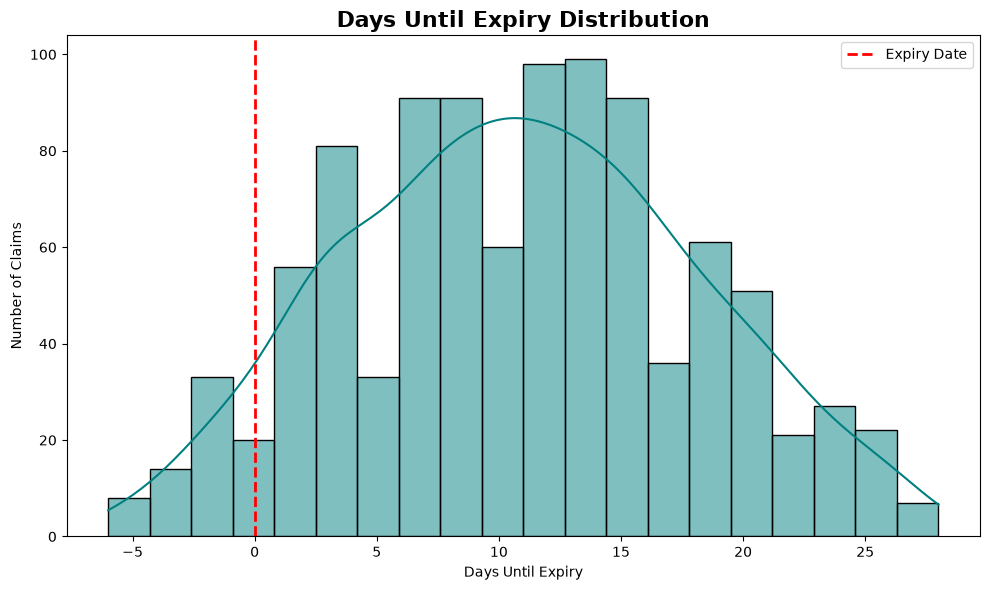

In [17]:
# ============================================
# DAYS UNTIL EXPIRY DISTRIBUTION
# ============================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=claims_analysis,
    x="Days_Until_Expiry",
    bins=20,
    kde=True,
    color="teal"
)

plt.axvline(
    x=0,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Expiry Date"
)

plt.title(
    "Days Until Expiry Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Days Until Expiry")
plt.ylabel("Number of Claims")

plt.legend()

plt.tight_layout()

plt.savefig(
    "Image/days_until_expiry_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Insight

Most food claims occur well before the expiry date, with an average lead time of approximately 10.9 days. The distribution is concentrated in the positive range, indicating that the platform generally facilitates food redistribution before products expire. However, the small portion of the distribution falling below zero represents 55 claims (5.5%) made after expiry, including 15 completed claims. For stakeholders, this suggests that while the platform is largely effective at preventing food waste, there may be opportunities to strengthen expiry monitoring and claim validation processes.

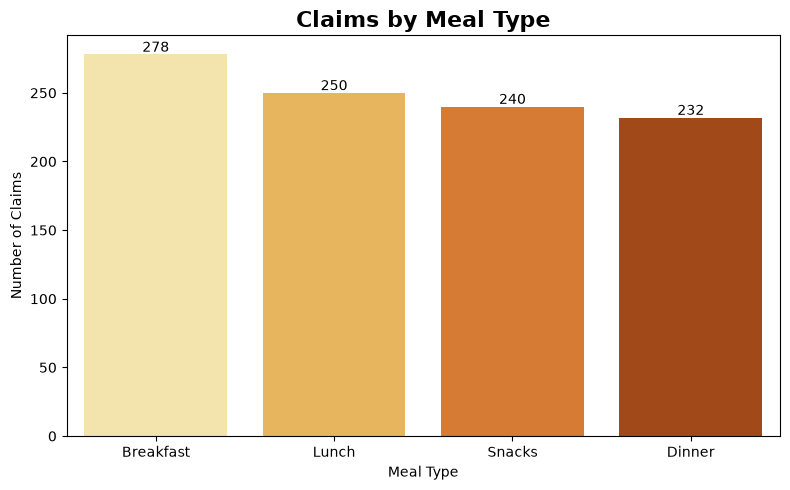

In [18]:
# ============================================
# CLAIMS BY MEAL TYPE
# ============================================

claims_meal_type = claims.merge(
    food_listings[["Food_ID", "Meal_Type"]],
    on="Food_ID",
    how="left"
)

meal_claims = (
    claims_meal_type["Meal_Type"]
    .value_counts()
    .reset_index()
)

meal_claims.columns = ["Meal_Type", "Claim_Count"]

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=meal_claims,
    x="Meal_Type",
    y="Claim_Count",
    hue="Meal_Type",
    palette="YlOrBr",
    legend=False
)

plt.title(
    "Claims by Meal Type",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Meal Type")
plt.ylabel("Number of Claims")

# Value labels
for i, row in meal_claims.iterrows():
    ax.text(
        i,
        row["Claim_Count"] + 2,
        str(row["Claim_Count"]),
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "Image/claims_by_meal_type.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Insight

Breakfast generated the highest number of claims (278), compared with 254 available breakfast listings, resulting in a claim-to-listing ratio above 1.0. In contrast, Lunch (250 claims vs. 248 listings), Snacks (240 vs. 253), and Dinner (232 vs. 245) showed demand levels that more closely matched availability.

Comparing this chart with the Meal Type Distribution chart suggests that demand generally mirrors supply across meal categories, but Breakfast exhibits slightly stronger demand relative to availability. For stakeholders, this may indicate an opportunity to prioritize breakfast donations to better align food supply with recipient demand.